In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# Load the data:
from google.colab import files
uploaded = files.upload()

Saving iris.csv to iris.csv


In [ ]:
iris_dataset = pd.read_csv("iris.csv", sep=',')
display(iris_dataset)

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica


# Explore the data

In [ ]:
# Explore the data
print("Keys of iris_dataset:\n", iris_dataset.keys())
# What are the target names?
print("Target names:\n", np.unique(iris_dataset['variety']))
# Feature names:
print("Feature names:\n", iris_dataset.keys()[0:4])
# Type of data:
print("Type of data:\n", type(iris_dataset['sepal.length'][:]))
# 

Keys of iris_dataset:
 Index(['sepal.length', 'sepal.width', 'petal.length', 'petal.width',
       'variety'],
      dtype='object')
Target names:
 ['Setosa' 'Versicolor' 'Virginica']
Feature names:
 Index(['sepal.length', 'sepal.width', 'petal.length', 'petal.width'], dtype='object')
Type of data:
 <class 'pandas.core.series.Series'>


# Measuring performance

In [ ]:
# Convert string target vector to integer
y=pd.factorize(iris_dataset['variety'])
#display(y)
X = iris_dataset.loc[:,'sepal.length':'petal.width']
#display(y[1][2])
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y[0], random_state=0)
display(X_test)


,sepal.length,sepal.width,petal.length,petal.width
114,5.8,2.8,5.1,2.4
62,6.0,2.2,4.0,1.0
33,5.5,4.2,1.4,0.2
107,7.3,2.9,6.3,1.8
7,5.0,3.4,1.5,0.2
100,6.3,3.3,6.0,2.5
40,5.0,3.5,1.3,0.3
86,6.7,3.1,4.7,1.5
76,6.8,2.8,4.8,1.4
71,6.1,2.8,4.0,1.3


In [ ]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (135, 4)
y_train shape: (135,)


In [ ]:
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (15, 4)
y_test shape: (15,)


# Data exploration

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7fdf8b05c780>,
      dtype=object)

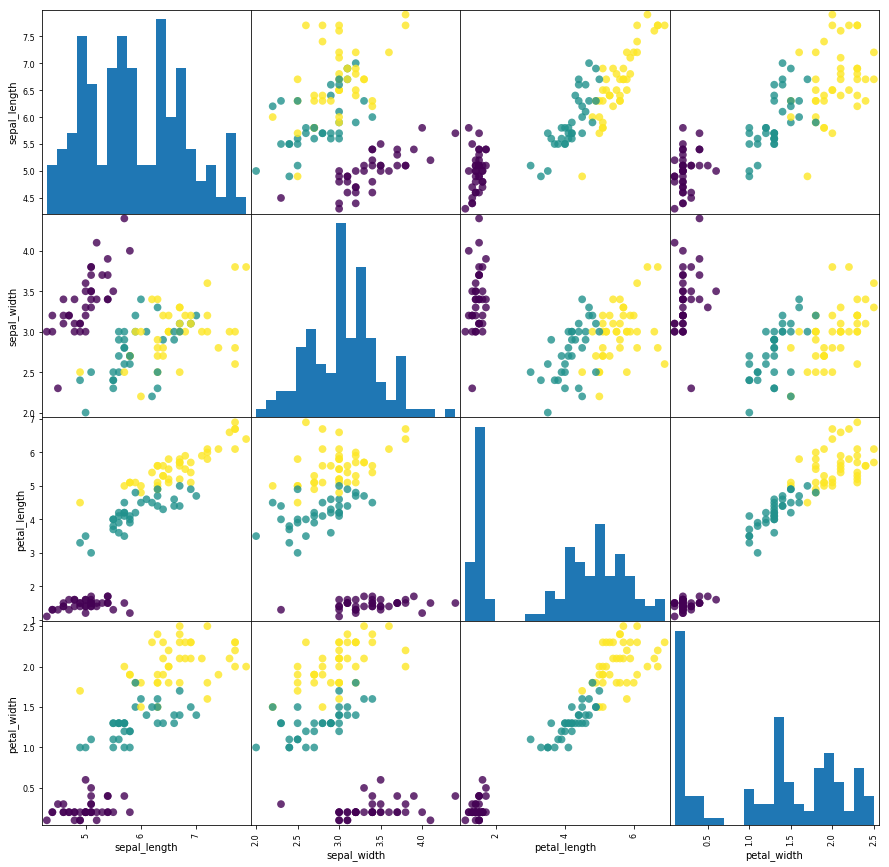

In [ ]:
# create dataframe from data in X_train
# label the columns using the strings in iris_dataset.feature_names
iris_dataframe = pd.DataFrame(X_train, columns=iris_dataset.keys()[0:4])
# create a scatter matrix from the dataframe, color by y_train
pd.plotting.scatter_matrix(iris_dataframe, c=y_train, figsize=(15, 15),
                           marker='o', hist_kwds={'bins': 20}, s=60,
                           alpha=.8)

# Building Your First Model: k-Nearest Neighbors

In [ ]:
#Create learning object and model
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=1)

In [ ]:
#Train the model
knn.fit(X_train, y_train)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
                     metric_params=None, n_jobs=None, n_neighbors=1, p=2,
                     weights='uniform')

# Make predictions / predictions

In [ ]:
X_new = np.array([[5, 2.9, 1, 0.2]])
print("X_new.shape:", X_new.shape)

X_new.shape: (1, 4)


In [ ]:
prediction = knn.predict(X_new)
print("Prediction:", prediction)
print("Predicted target name:", y[1][prediction])

Prediction: [0]
Predicted target name: Index(['Setosa'], dtype='object')


# Evaluating the models:

In [ ]:
y_pred = knn.predict(X_test)
print("Test set predictions:\n", y_pred)

Test set predictions:
 [2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 1]


In [ ]:
print("Test set score: {:.2f}".format(np.mean(y_pred == y_test)))

Test set score: 1.00


In [ ]:
print("Test set score: {:.2f}".format(knn.score(X_test, y_test)))

Test set score: 1.00


### Summary and Outlook

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    iris_dataset.loc[:,'SepalLengthCm':'PetalWidthCm'], y[0], random_state=0)
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)

print("Test set score: {:.2f}".format(knn.score(X_test, y_test)))

Test set score: 0.97
